<a href="https://colab.research.google.com/github/thiendoan0401-hue/HW1/blob/main/HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name**: Thien Doan

SJSU ID: 018793021

GitHub link: https://github.com/f26-sjsu-cmpe188/Iris/blob/3b0021abb7b475f426bcfa07937998c4288098e0/Iris_ClassDemo.ipynb$0

**Advanced Task 1**

**1.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Data points, x0 always is 1
X = np.array([
    [1, 0.5, 1.5],
    [1, 1.8, 0.4],
    [1, 0.3, 1.8],
    [1, 2.0, 0.6],
    [1, 0.7, 1.2],
    [1, 1.5, 0.3],
    [1, 0.2, 2.0],
    [1, 1.9, 0.8],
    [1, 0.9, 1.6],
    [1, 1.6, 0.5]
])
X.shape

(10, 3)

In [3]:
# Labels
y = np.array([
    0, 1, 0, 1, 0,
    1, 0, 1, 0, 1
])
y.shape

(10,)

In [4]:
# Original weights (last digit = 1)
w = np.array([-0.9, 0.65, -0.27])

# Given learning rate
eta = 0.5

w.shape

(3,)

For one point, mathematically:

s_i=w^T @ x_i

Because your data points are stored as rows in \(X\), Python can calculate all 10 simultaneously:

s=X @ w

In [5]:
from math import exp
def predict_proba(X, w):
  """X: (N, d+1) array with a leading bias column of 1s. w: (d+1,) array.
  Returns sigma(X @ w), shape (N,)."""
  s = X @ w
  # print(s.shape)
  return 1 / (1 + np.exp(-s))

In [6]:
def cross_entropy_loss(y, y_prob):
  """y: (N,) array of 0/1 labels. y_prob: (N,) array of predicted probabilities.
  Returns the average cross-entropy loss (a scalar)."""

  # Return Loss at each points
  # return -(y * np.log(y_prob) + (1- y) * np.log(1 - y_prob))

  # Return average cross-entropy loss
  return -np.mean(y * np.log(y_prob) + (1- y) * np.log(1 - y_prob))

In [7]:
def gradient_step(X, y, w, eta):
  """One batch gradient-descent update. Returns the new weight vector w'."""
  y_prob = predict_proba(X, w)
  # y_prob (10, 1)

  # X (10, 3)
  grad = X.T @ (y_prob - y)
  # grad (3, 1)

  w_new = w - eta * grad
  return w_new

In [8]:
p1 = predict_proba(X, w)

print("Round 1 probabilities:")
print(p1.shape)
print(p1)

print("Round 1 average loss:")
print(cross_entropy_loss(y, p1))

Round 1 probabilities:
(10,)
[0.27289178 0.54041166 0.23308013 0.55922072 0.31669547 0.4985
 0.21248684 0.52971494 0.32147534 0.50125   ]
Round 1 average loss:
0.481043059515585


**Advanced Task 1.1**

Using your Task 1 (Core) dataset and starting weight vector, run gradient_step for one
iteration and confirm your code's output matches your by-hand Round 2 weights and
total loss from the Core task. This is your correctness check — if they don't match, find
the bug before moving on.

In [9]:
w2 = gradient_step(X, y, w, eta)

print("Round 2 weights:")
print(w2)

p2 = predict_proba(X, w2)

print("Round 2 average loss:")
print(cross_entropy_loss(y, p2))

Round 2 weights:
[-0.39286344  2.34636362 -0.73194738]
Round 2 average loss:
0.3163157757771221


**Confirmed that hand calculation is correct for Task 1.1, 1.2 and 1.3**

**Advanced Task 1.2**

Then run 50+ iterations of batch gradient descent (same η = 0.5, or try a couple of
values) and plot total cross-entropy loss vs. iteration.

In [10]:
w = np.array([-0.9, 0.65, -0.27])

loss_history = []
for i in range(50):
  y_prob = predict_proba(X, w)
  loss = cross_entropy_loss(y, y_prob)
  loss_history.append(loss)
  w = gradient_step(X, y, w, eta)

print(f"final weight vector: {w}")
print(f"final loss: {loss}")

final weight vector: [-1.24694625  4.89188861 -4.6552322 ]
final loss: 0.00941226084177788


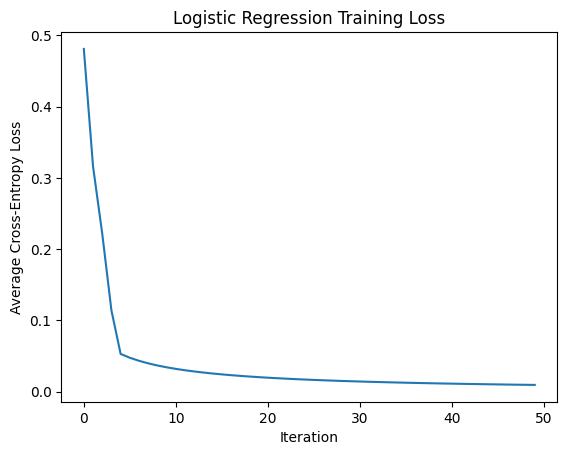

In [11]:
plt.plot(loss_history)

# plt.plot(range(50), loss_history)

plt.xlabel("Iteration")
plt.ylabel("Average Cross-Entropy Loss")
plt.title("Logistic Regression Training Loss")

plt.show()

**Advanced Task 1.3**

Discuss: Does the loss curve keep decreasing the whole time, or does it flatten out? At
what iteration would you have stopped training, and why?

The plot begins to flatten out after approximately 30 iterations. I would stop training when the loss reaches approximately 0.01. Because the loss is already very close to zero, and further training would provide only a small improvement.

**Task 2 - The Digits Dataset 1 vs 5**

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

**Task 2 (Advanced) Extract intensity & symmetry**

In [14]:
df = pd.read_csv("/content/drive/MyDrive/cmpe188_hw1/zipdigits_1vs5_train_raw.csv", header= None)

In [15]:
# Data labels (first column)
raw_labels = df.iloc[1:, 0].to_numpy()

# Data pixels (second column -> end)
pixels = df.iloc[1:, 1:].to_numpy()

print(raw_labels.shape)
print(pixels.shape)

(1112,)
(1112, 256)


**The first column label is the raw digit id (1 or 5). You'll need to
turn this into a target yourself (e.g., 1 → 1, 5 → 0).**

In [16]:
y = (raw_labels == '1').astype(int)

print(f"Total 1s: {np.count_nonzero(y == 1)}")
print(f"Total 0s: {np.count_nonzero(y == 0)}")

# The number of labels for 1 and 5 are equal

Total 1s: 556
Total 0s: 556


**Each row's 256 pixel values reshape into a
16×16 image**

In [17]:
# By using reshape(-1, 16, 16)
# 256 = 16 x 16
# -1 will make it automatically figure out the dimension
# it is auto filled as pixels.reshape(1112, 16, 16)

images = pixels.reshape(-1, 16, 16)

print(images.shape)

(1112, 16, 16)


In [18]:
print(images[0,0,0])

-1.0


**def extract_features(images)**

In [19]:
print(images[0,0,0])

# The top left corner is white color => white pixel correspoding to -1

-1.0


In [20]:
def extract_features(images):
  """
  images: numpy array of shape (N, 16, 16), pixel values in [-1, 1]
  returns: numpy array of shape (N, 2), columns = [intensity, symmetry], in that
  order
  """

  # Intensity
  # Intensity: rescale each pixel (if necessary) to have higher values for white pixels, then
  # average all 256 rescaled pixels.
  # [-1, 1] -> [1, 0]
  rescaled_images = (1 - images) / 2
  intensity = np.mean(rescaled_images, axis=(1, 2))

  # Symmetry: flip the image left-right or top-down and compute the average of image * flipped_image over all 256 pixels. A more symmetric digit scores higher.
  # symmetry = avg (flipped_image * image)
  flipped_image = np.flip(images, axis=2)
  symmetry = np.mean(flipped_image * images, axis=(1,2))
  return np.column_stack((intensity, symmetry))

**Task 2 (Core) E_in vs. E_out**

1. Load your feature set (from the Advanced task, or the fallback CSV. Both have columns
intensity, symmetry, label, for the same 1112 images).

In [21]:
# Original data are in string type -> convert to float
image_as_float = np.asarray(images, dtype=float)

# Reshape the convert image
image_as_float = image_as_float.reshape(-1, 16, 16)

# Load feature set
features = extract_features(image_as_float)
print(features.shape)

(1112, 2)


2. Split it into your own train/test partition: train_test_split(..., test_size=0.3,
random_state=42, stratify=y). Your training split gives you E_in; your held-out split gives
you E_out (this is your own internal estimate).

In [22]:
X = features
y = (raw_labels == '1').astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)



X shape: (1112, 2)
y shape: (1112,)


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size= 0.3,
    random_state = 42,
    stratify= y)

3. Fit four classifiers on your training split: LogisticRegression, and KNeighborsClassifier
with n_neighbors = 1, 3, 5. For each, compute the error rate (1 − accuracy) on both your
training split (E_in) and your test split (E_out).

In [24]:
# Create models
models ={
    "Logistic Regression": LogisticRegression(),
    "KNN 1": KNeighborsClassifier(n_neighbors=1),
    "KNN 3": KNeighborsClassifier(n_neighbors=3),
    "KNN 5": KNeighborsClassifier(n_neighbors=5)
}

In [25]:
model_names =[]
ein_values = []
eout_values = []

for name, model in models.items():
  # Fit model
  model.fit(X_train, y_train)

  # Predict
  y_pred_train = model.predict(X_train)
  y_pred_test = model.predict(X_test)

  # Calculate ein and eout
  ein = 1 - accuracy_score(y_train, y_pred_train)
  eout = 1 - accuracy_score(y_test, y_pred_test)

  # append to the list
  model_names.append(name)
  ein_values.append(ein)
  eout_values.append(eout)

  print(name)
  print("E_in :", ein)
  print("E_out:", eout)
  print()

Logistic Regression
E_in : 0.014138817480719768
E_out: 0.020958083832335328

KNN 1
E_in : 0.0
E_out: 0.017964071856287456

KNN 3
E_in : 0.007712082262210762
E_out: 0.014970059880239472

KNN 5
E_in : 0.010282776349614386
E_out: 0.0119760479041916



4. Make one grouped bar chart: 4 models on the x-axis, two bars per model (E_in, E_out).
We worked on a similar experiment with a Synthetic dataset. Added as a reference
below.

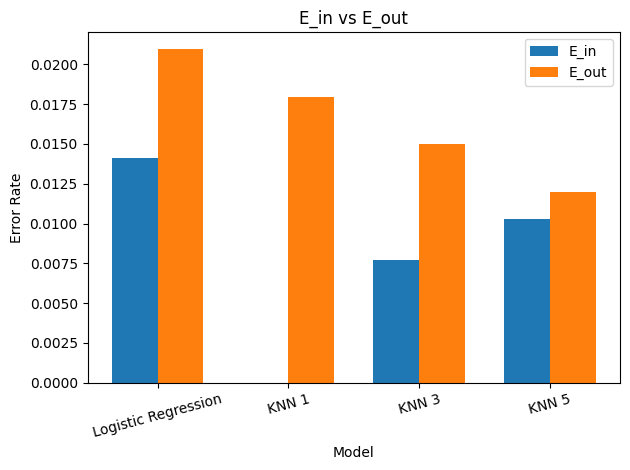

In [26]:
x = np.arange(len(model_names))
width = 0.35

plt.bar(x - width/2, ein_values, width, label="E_in")
plt.bar(x + width/2, eout_values, width, label="E_out")

plt.xticks(x, model_names, rotation=15)
plt.ylabel("Error Rate")
plt.xlabel("Model")
plt.title("E_in vs E_out")
plt.legend()

plt.tight_layout()
plt.show()

5. Discuss: Which model would you recommend for this task, and why? Point to specific numbers in your bar chart. For example, does 1-NN have a suspiciously low E_in but a much higher E_out than the others? What does that gap suggest about that model's complexity relative to this dataset?


- In this task I would recommend the model KNN(n_neighbor = 5).

- According to the bar chart, it has the smallest gap between ein and eout, which suggests that it generalizes better to unseen data.

- If the gap is large, the model performs much better on the training data than on the testing data, which indicates overfitting. If the gap is small, the model generalizes better because its training and testing errors are similar.

### AI Use Note

ChatGPT was used as a learning and debugging assistant during this project. It helped explain the mathematical concepts and Python functions used in the assignment, including logistic regression, cross-entropy loss, gradient descent, feature extraction, intensity, symmetry, and NumPy operations. AI was also used to help identify and understand coding errors and to improve the clarity of written explanations. The final code was reviewed, tested, and understood before submission.